# Deep Learning Foundations: Multilayer Perceptrons (MLP) and Loss Mechanics

Building on single-neuron fundamentals, this notebook maps out the transition to Multilayer Perceptrons (MLPs). Stacking layers expands a network's computational capability, shifting from simple linear approximations to complex non-linear classification systems necessary for complex modern architectures.

--- 
## 1. Detailed Anatomy of an MLP

A single neuron draws a single line. A Multilayer Perceptron draws a complex boundary by stacking those lines. This architecture consists of three distinct types of layers:

1. **The Input Layer ($l=0$):** This layer does no processing. It acts as a conduit to receive raw features (e.g., pixels of an image, or encoded tokens in a sentence). For instance, if we are classifying a $28 \times 28$ pixel image, this layer consists of exactly 784 passive input nodes.
2. **The Hidden Layers:** This is where abstract features are extracted. A deep neural network can contain numerous hidden layers. For instance, in image processing, the first hidden layer might isolate basic edges; the second might identify intermediate shapes (like an ear); a third layer can synthesize those features to recognize a complex object (like a cat). Each hidden neuron maintains its own unique weight and bias parameters.
3. **The Output Layer:** The final layer that maps hidden representations to a final prediction. For binary classification (e.g., Cat vs. Dog), a single neuron using a Sigmoid function outputs a value between 0 and 1. For a multiclass objective (like the 1,000-class ImageNet challenge), this layer contains 1,000 neurons evaluated using a Softmax function.

--- 
## 2. Explanation of Forward Propagation

Forward propagation is the process of moving data linearly forward from input to output, layer by layer, in a single sequential pass. This step is purely dedicated to inference (making a guess); no weight adjustment or learning occurs during this phase.

### The Lifecycle of Data During the Forward Pass
Using $l$ to index layers and indices $i, j$ for individual neurons, we trace the forward transformation:

* **Layer 0 (Inputs):** The initial input vector is denoted as $a^{(0)}$ (activations of layer 0). For standard binary logic operations, this vector represents $a^{(0)} = [x_1, x_2]$.
* **Transition from Layer $l$ to Layer $l+1$:** For every single neuron $j$ in the receiving layer $l+1$, two distinct operations take place:
    1. **The Linear Step (Weighted Sum):** Neuron $j$ evaluates all upstream activations ($a_i^{(l)}$) from the previous layer $l$. It multiplies each incoming activation by its corresponding weight ($w_{ji}^{(l+1)}$), sums the products, and appends its internal bias ($b_j^{(l+1)}$) to establish a pre-activation sum $z_j^{(l+1)}$:
    $$z_j^{(l+1)} = \sum_{i} (a_i^{(l)} \cdot w_{ji}^{(l+1)}) + b_j^{(l+1)}$$
    2. **The Non-Linear Step (Activation):** The neuron maps that pre-activation value $z$ through a non-linear activation function ($f$) such as ReLU, Sigmoid, or Tanh. This produces the final activation vector element ($a_j^{(l+1)}$) for that specific node:
    $$a_j^{(l+1)} = f(z_j^{(l+1)})$$

This cycle repeats sequentially. The activations of the current hidden layer ($a^{(l+1)}$) serve as the input nodes for the subsequent layer until the data arrives at the final **Output Layer**. The final evaluations represent the network's system prediction (denoted as $\hat{y}$ or $h_\theta(x)$).

--- 
## 3. The Math: Hidden Layer Matrix Transformations

Computing calculations node-by-node using standard nested loops is computationally inefficient. To process thousands of features in parallel, modern models rely heavily on matrix operations, which match the core processing strengths of GPUs.

### Formalizing Matrix Notation
* Let $L$ be the total number of layers within the system (including the input layer).
* Let $n^{[l]}$ denote the exact number of neurons present in layer $l$.

We can structure weights and biases into compact matrices for any destination layer $l+1$:

* **Weight Matrix ($W^{[l+1]}$):** This matrix maps incoming activations from layer $l$ to the pre-activations of layer $l+1$. Its dimensions are strictly $(n^{[l+1]}, n^{[l]})$. If Hidden Layer 1 has 4 neurons and Input Layer 0 has 3 features, $W^{[1]}$ is a $(4 \times 3)$ matrix:
$$W^{[l+1]} = \begin{bmatrix} w_{11} & w_{12} & w_{13} \\ w_{21} & w_{22} & w_{23} \\ w_{31} & w_{32} & w_{33} \\ w_{41} & w_{42} & w_{43} \end{bmatrix}$$
*Crucially, the rows match the destination layer count $n^{[l+1]}$, while the columns align with the source layer feature count $n^{[l]}$.*

* **Bias Vector ($b^{[l+1]}$):** A simple column vector housing the specific scalar bias term for every neuron in the destination layer. It maintains the dimensions $(n^{[l+1]}, 1)$:
$$b^{[1]} = \begin{bmatrix} b_1 \\ b_2 \\ b_3 \\ b_4 \end{bmatrix}$$

* **Activation Vector ($a^{[l]}$):** A column vector holding the inputs passed forward from the preceding layer, keeping the dimensional shape $(n^{[l]}, 1)$.

### Bridging Neurons to the Matrix Structure
While each neuron maintains an independent weight vector, they pack cleanly together. For an input layer with 2 features ($x_1, x_2$) and a hidden layer with 3 neurons, each neuron evaluates a distinct pattern:
* Neuron 1 Weight Vector: $\vec{w}_1 = [0.1, -0.5]$
* Neuron 2 Weight Vector: $\vec{w}_2 = [0.2, 0.3]$
* Neuron 3 Weight Vector: $\vec{w}_3 = [-0.1, 0.8]$

Stacking these row vectors on top of each other constructs our layer weight matrix:
$$W = \begin{bmatrix} \leftarrow & \vec{w}_1 & \rightarrow \\ \leftarrow & \vec{w}_2 & \rightarrow \\ \leftarrow & \vec{w}_3 & \rightarrow \end{bmatrix} = \begin{bmatrix} 0.1 & -0.5 \\ 0.2 & 0.3 \\ -0.1 & 0.8 \end{bmatrix}$$

When computing $Z = W \cdot X + b$, the linear algebra expands parallel calculations across each row automatically:
$$Z = \begin{bmatrix} 0.1 & -0.5 \\ 0.2 & 0.3 \\ -0.1 & 0.8 \end{bmatrix} \cdot \begin{bmatrix} x_1 \\ x_2 \end{bmatrix} + \begin{bmatrix} b_1 \\ b_2 \\ b_3 \end{bmatrix}$$
$$\text{Neuron 1: } z_1 = (0.1 \cdot x_1) + (-0.5 \cdot x_2) + b_1$$
$$\text{Neuron 2: } z_2 = (0.2 \cdot x_1) + (0.3 \cdot x_2) + b_2$$
$$\text{Neuron 3: } z_3 = (-0.1 \cdot x_1) + (0.8 \cdot x_2) + b_3$$

### Vectorized Mathematical Step
Using vector mathematics, we perform the linear pass across an entire layer simultaneously:
$$Z^{[l+1]} = W^{[l+1]} \cdot a^{[l]} + b^{[l+1]}$$
$$\text{Dimensional Check: } (4 \times 3) \cdot (3 \times 1) \rightarrow (4 \times 1) + (4 \times 1) \rightarrow (4 \times 1)$$

Next, we compute the non-linear transformation element-wise:
$$A^{[l+1]} = f(Z^{[l+1]})$$

#### Trace Example:
Given $a^{[0]} = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$, $W^{[1]} = \begin{bmatrix} 0.1 & -0.5 \\ 0.2 & 0.3 \\ -0.1 & 0.8 \end{bmatrix}$, and $b^{[1]} = \begin{bmatrix} -0.1 \\ 0.1 \\ -0.2 \end{bmatrix}$:
$$Z^{[1]} = \begin{bmatrix} 0.1 & -0.5 \\ 0.2 & 0.3 \\ -0.1 & 0.8 \end{bmatrix} \cdot \begin{bmatrix} 1 \\ 0 \end{bmatrix} + \begin{bmatrix} -0.1 \\ 0.1 \\ -0.2 \end{bmatrix} = \begin{bmatrix} 0.1 \\ 0.2 \\ -0.1 \end{bmatrix} + \begin{bmatrix} -0.1 \\ 0.1 \\ -0.2 \end{bmatrix} = \begin{bmatrix} 0 \\ 0.3 \\ -0.3 \end{bmatrix}$$

Applying an element-wise ReLU function ($\max(0, z)$) yields the hidden activation vector:
$$A^{[1]} = \begin{bmatrix} \max(0, 0) \\ \max(0, 0.3) \\ \max(0, -0.3) \end{bmatrix} = \begin{bmatrix} 0 \\ 0.3 \\ 0 \end{bmatrix}$$

This vector $A^{[1]}$ is passed to the output layer parameters ($W^{[2]}, b^{[2]}$) to calculate the network's final classification scalar prediction $\hat{y}$ ($A^{[2]}$).

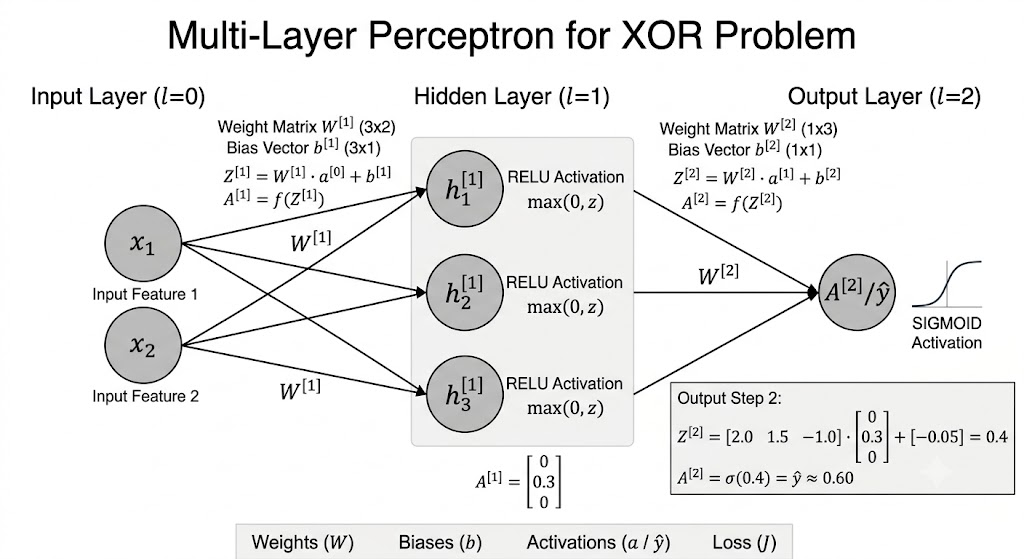

--- 
## 4. Loss Functions and Binary Cross-Entropy (BCE)

Once an output layer produces a prediction vector ($A^{[L]}$), we must evaluate its performance using a **Loss Function** ($J$). A loss function maps network estimations ($\hat{y}$) against ground-truth labels ($y$) to generate a single scalar value representing the performance penalty.

For regression scenarios, **Mean Squared Error (MSE)** is commonly used:
$$MSE = \frac{1}{2} (\hat{y} - y)^2$$

For classification scenarios where the output layer is bounded between 0 and 1 via a Sigmoid function, **Binary Cross-Entropy (BCE)** is the mathematical standard:
$$L(\hat{y}, y) = - \left( y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right)$$

### Understanding the Information Theory Behind BCE
To understand why it is called **Binary Cross-Entropy**, we look to the concept of **Entropy** in information theory, pioneered by Claude Shannon. In simple terms, entropy measures the average uncertainty or surprise in a system. If an event is 100% certain to happen, its entropy is zero because there is no surprise.

When training a classifier, we look at two distinct probability distributions:
1. **The True Distribution ($y$):** The actual ground-truth label ($y=1$ or $y=0$). This is the absolute truth, representing a system with zero uncertainty.
2. **The Predicted Distribution ($\hat{y}$):** The probability calculated by our neural network (e.g., $\hat{y}=0.75$).

**Cross-Entropy** measures the average number of bits needed to identify an event from a target distribution if we use a coding scheme optimized for a *predicted* distribution rather than the *true* one. In plain language, it measures how much extra "surprise" we experience because our network's predictions do not perfectly match the absolute truth. The word *Binary* simply indicates we are evaluating two possible classes (0 or 1).

### The Mathematical Mechanics of the BCE Equation
The equation changes based on the value of the ground truth label:

* **Case 1: The True Label is $y = 1$**
  When $y=1$, the second term $(1 - y)$ becomes exactly $0$, dropping out of the calculation. We are left with:
  $$L(\hat{y}, 1) = -\log(\hat{y})$$
  * If the network predicts confidently and correctly ($\hat{y} = 0.99$), $-\log(0.99) \approx 0.01$, resulting in a minimal loss penalty.
  * If the network predicts confidently but incorrectly ($\hat{y} = 0.01$), $-\log(0.01) \approx 4.6$, causing the loss curve to shoot sharply upward toward infinity.

* **Case 2: The True Label is $y = 0$**
  When $y=0$, the first term component drops out. We are left with:
  $$L(\hat{y}, 0) = -\log(1 - \hat{y})$$
  This relationship mirrors Case 1, but heavily penalizes any predictions that approach `1` when the target is `0`.

--- 
## 5. Python Sandbox: Multi-Layer Perceptron for XOR Optimization

The code cell below implements a complete Multilayer Perceptron utilizing NumPy matrix mechanics. It includes both **Forward Propagation** and **Backpropagation** (via Gradient Descent) to solve the non-linearly separable XOR problem.

### Matrix Layout for the XOR Network
* **Input to Hidden Layer ($W^{[1]}$):** A $(3 \times 2)$ shape matrix mapping 2 incoming raw features into 3 independent hidden neurons.
* **Hidden to Output Layer ($W^{[2]}$):** A $(1 \times 3)$ shape matrix mapping the 3 hidden activations into 1 final prediction value.

In [2]:
import numpy as np

class MultilayerPerceptron:
    def __init__(self, input_dim=2, hidden_dim=3, output_dim=1, lr=0.1):
        np.random.seed(42)  # For reproducible results
        
        # Layer 1: Input -> Hidden (3 neurons, 2 inputs each)
        self.W1 = np.random.randn(hidden_dim, input_dim) * 0.1
        self.b1 = np.zeros((hidden_dim, 1))
        
        # Layer 2: Hidden -> Output (1 neuron, 3 inputs each)
        self.W2 = np.random.randn(output_dim, hidden_dim) * 0.1
        self.b2 = np.zeros((output_dim, 1))
        
        self.lr = lr
 
    def relu(self, Z):
        return np.maximum(0, Z)
 
    def relu_derivative(self, Z):
        return (Z > 0).astype(float)
 
    def sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))
 
    def sigmoid_derivative(self, A):
        # Derivative of sigmoid in terms of its output A
        return A * (1 - A)
 
    def forward(self, X):
        # X shape expected: (input_dim, batch_size)
        # --- Layer 1 (Hidden) ---
        self.Z1 = np.dot(self.W1, X) + self.b1
        self.A1 = self.relu(self.Z1)
        
        # --- Layer 2 (Output) ---
        self.Z2 = np.dot(self.W2, self.A1) + self.b2
        self.A2 = self.sigmoid(self.Z2)
        return self.A2
 
    def backward(self, X, Y):
        m = X.shape[1]  # Number of samples
        
        # 1. Output error (using Binary Cross-Entropy derivative combined with Sigmoid)
        dZ2 = self.A2 - Y
        dW2 = (1 / m) * np.dot(dZ2, self.A1.T)
        db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
        
        # 2. Backpropagate error to hidden layer
        dA1 = np.dot(self.W2.T, dZ2)
        dZ1 = dA1 * self.relu_derivative(self.Z1)  # Mask out negative values
        dW1 = (1 / m) * np.dot(dZ1, X.T)
        db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
        
        # 3. Gradient Descent parameter updates
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
 
    def compute_loss(self, A2, Y):
        m = Y.shape[1]
        # Binary Cross-Entropy loss formula with added small constant epsilon to prevent log(0)
        loss = - (1 / m) * np.sum(Y * np.log(A2 + 1e-15) + (1 - Y) * np.log(1 - A2 + 1e-15))
        return loss
 
# --- Execution ---
if __name__ == "__main__":
    # XOR inputs and targets
    # Note: Data transposed so each column is one training sample: shape (2, 4)
    X = np.array([[0, 0, 1, 1],
                  [0, 1, 0, 1]])
    Y = np.array([[0, 1, 1, 0]]) # Target XOR outputs: shape (1, 4)
 
    mlp = MultilayerPerceptron(input_dim=2, hidden_dim=3, output_dim=1, lr=0.5)
    
    print("Training the Multilayer Perceptron on XOR...")
    for epoch in range(1000):
        predictions = mlp.forward(X)
        loss = mlp.compute_loss(predictions, Y)
        mlp.backward(X, Y)
        
        if (epoch + 1) % 200 == 0:
            print(f"Epoch {epoch + 1}/1000 - Loss: {loss:.4f}")
            
    # Final verification
    final_preds = mlp.forward(X)
    print("\nFinal Trained Predictions:")
    for i in range(4):
        print(f"Input: [{X[0,i]}, {X[1,i]}] -> Predicted Probability: {final_preds[0,i]:.4f} (Target: {Y[0,i]})")

Training the Multilayer Perceptron on XOR...
Epoch 200/1000 - Loss: 0.0634
Epoch 400/1000 - Loss: 0.0138
Epoch 600/1000 - Loss: 0.0074
Epoch 800/1000 - Loss: 0.0050
Epoch 1000/1000 - Loss: 0.0037

Final Trained Predictions:
Input: [0, 0] -> Predicted Probability: 0.0062 (Target: 0)
Input: [0, 1] -> Predicted Probability: 0.9987 (Target: 1)
Input: [1, 0] -> Predicted Probability: 0.9987 (Target: 1)
Input: [1, 1] -> Predicted Probability: 0.0062 (Target: 0)
